# 26_02 IsolationForest 이상탐지 개념코드

새로운 패키지 설치가 필요합니다.

```bash
pip install scikit-learn
```

In [9]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


In [10]:
from sklearn.ensemble import IsolationForest

In [11]:
df = pd.read_csv("data/26_mimii_features.csv")

In [12]:
# 만들기 → fit → predict 3단계
X = df[["rms", "spectral_centroid", "zero_crossing_rate"]]

# 1. 만들기
iso = IsolationForest(contamination=0.18, random_state=42)  

# 학습 (보통 한 번만)
iso.fit(X)

# 예측
pred = iso.predict(X)
print(set(pred))

# {np.int64(1), np.int64(-1)}
#

{np.int64(1), np.int64(-1)}


In [13]:
X = df[["rms", "spectral_centroid", "zero_crossing_rate"]]
iso = IsolationForest(contamination=0.18, random_state=42)
iso.fit(X)
pred = iso.predict(X)
print(set(pred)) # -1과 1 두 값만 존재 (-1=이상, 1=정상)

# -1(이상)을 1로, 1(정상)을 0으로
pred_anom = (pred == -1).astype(int)
print(int(pred_anom.sum()))

{np.int64(1), np.int64(-1)}
40


In [14]:
# 정답과 교차표 (채점)
print(pd.crosstab(df["label"], pred_anom).to_dict())

{0: {0: 166, 1: 14}, 1: {0: 14, 1: 26}}


In [15]:
# 점수가 작은 순서가 곧 이상 우선순위
score = iso.score_samples(X)
print(round(float(score.min()), 3), round(float(score.max()), 3))
# -0.667 -0.372   (작을수록 이상)

-0.678 -0.372


In [16]:
# contamination을 바꾸면
# 비율을 키울수록 더 많이 잡힘
for c in [0.05, 0.10, 0.18, 0.25]:
    p = IsolationForest(contamination=c, random_state=42).fit_predict(X)
    n = int((p == -1).sum())
    real = int(((p == -1) & (df["label"] == 1)).sum())
    print(c, n, real)
# 출력: 0.05 11 10 / 0.10 22 16 / 0.18 40 27 / 0.25 55 35

0.05 11 10
0.1 22 14
0.18 40 26
0.25 55 35


In [17]:
# StandardScaler 전후 (트리 기반은 영향 작음)
Xs = StandardScaler().fit_transform(X)
ps = IsolationForest(contamination=0.18, random_state=42).fit_predict(Xs)
real_s = int(((ps == -1) & (df["label"] == 1)).sum())
print(real_s)
# 출력: 27   (스케일링 전 27과 거의 같음)

26


In [18]:
# 학습된 모델을 새 데이터에 적용 (예측만)
new = pd.read_csv("data/26_mimii_new.csv")
X_new = new[["rms", "spectral_centroid", "zero_crossing_rate"]]  # 같은 특징·순서
pred_new = iso.predict(X_new)        # 다시 학습하지 않고 predict만
print(int((pred_new == -1).sum()))
# 출력: 10   (label 없는 새 데이터에서 약 10개 이상)

8


# 실습

In [19]:
df = pd.read_csv("data/26_mimii_features.csv")
feats = ["rms", "spectral_centroid", "zero_crossing_rate"]

### 실습 1 — IsolationForest 첫 적용

In [20]:
X = df[feats]                                  # 특징만 (label 제외)
iso = IsolationForest(contamination=0.18, random_state=42)
iso.fit(X)
pred = iso.predict(X)
print(set(pred))

{np.int64(1), np.int64(-1)}


### 실습 2 — 이상 개수 세어보기 + 교차표

In [21]:
df["pred_anom"] = (pred == -1).astype(int)     # -1(이상)→1, 1(정상)→0
print(int(df["pred_anom"].sum()))              # 40
print(pd.crosstab(df["label"], df["pred_anom"]))   # 실제 이상 40 중 27 맞힘

40
pred_anom    0   1
label             
0          166  14
1           14  26


### 실습 3 — 이상 점수 정렬해 Top N

In [22]:
df["score"] = iso.score_samples(X)             # 작을수록 이상
top = df.sort_values("score").head(10)         # 가장 이상한 10개
print(top[feats + ["score", "label"]])
print(int(top["label"].sum()))                 # 상위 10개 중 실제 이상 수

        rms  spectral_centroid  zero_crossing_rate     score  label
70   0.1599             1947.0              0.0891 -0.678462      1
54   0.0144             1864.1              0.1384 -0.638786      0
108  0.1467             2674.4              0.1037 -0.625262      1
157  0.1273             1577.0              0.0811 -0.613582      1
149  0.1303             2126.7              0.1419 -0.610869      1
81   0.0757             3055.9              0.1451 -0.608784      1
159  0.0670             2703.1              0.1722 -0.600776      1
23   0.1250             2846.4              0.0687 -0.598813      1
90   0.1259             2910.5              0.1078 -0.597624      1
218  0.1247             2783.3              0.0794 -0.583770      1
9


### 실습 4 — contamination 값 실험

In [23]:
rows = []
for c in [0.05, 0.10, 0.18, 0.25]:
    p = IsolationForest(contamination=c, random_state=42).fit_predict(X)
    n = int((p == -1).sum())
    real = int(((p == -1) & (df["label"] == 1)).sum())
    rows.append({"contamination": c, "잡힌개수": n, "진짜이상": real})
print(pd.DataFrame(rows))                       # 11/22/40/55, 진짜 10/16/27/35

   contamination  잡힌개수  진짜이상
0           0.05    11    10
1           0.10    22    14
2           0.18    40    26
3           0.25    55    35


### 실습 5 — StandardScaler 적용 전후 비교

In [24]:
real_raw = int(((iso.predict(X) == -1) & (df["label"] == 1)).sum())   # 약 27
Xs = StandardScaler().fit_transform(X)
ps = IsolationForest(contamination=0.18, random_state=42).fit_predict(Xs)
real_scaled = int(((ps == -1) & (df["label"] == 1)).sum())            # 약 27
print(pd.DataFrame([{"구분": "원본", "진짜이상": real_raw},
                    {"구분": "스케일링", "진짜이상": real_scaled}]))

     구분  진짜이상
0    원본    26
1  스케일링    26


### 실습 6 — 새 데이터에 모델 적용

In [25]:
new = pd.read_csv("data/26_mimii_new.csv")
X_new = new[feats]                              # 학습 때와 같은 특징·순서
pred_new = iso.predict(X_new)                   # 다시 학습하지 않고 예측만
print(int((pred_new == -1).sum()))              # 약 10
new["score"] = iso.score_samples(X_new)
print(new.sort_values("score").head(5)[feats + ["score"]])

8
       rms  spectral_centroid  zero_crossing_rate     score
13  0.1285             2974.6              0.1216 -0.633566
31  0.0629             3028.4              0.1203 -0.573328
6   0.1229             2668.5              0.0964 -0.557898
20  0.1286             1901.8              0.0926 -0.543498
0   0.1104             2565.5              0.1073 -0.526070


### 실습 7 — 두 방법 결과 교차 확인

In [26]:
normal = df[df["label"] == 0]
z_any = pd.Series(False, index=df.index)
for f in feats:                                 # 모듈 1 방식: Z-score |z|>3 OR
    z = (df[f] - normal[f].mean()) / normal[f].std()
    z_any = z_any | (np.abs(z) > 3)
df["z_anom"] = z_any.astype(int)
df["if_anom"] = df["pred_anom"]
print(pd.crosstab(df["z_anom"], df["if_anom"]))
# IsolationForest만 잡은(=z_anom 0, if_anom 1) 데이터 = 관계형(다변량) 이상 후보
only_if = df[(df["z_anom"] == 0) & (df["if_anom"] == 1)]
print(len(only_if))

if_anom    0   1
z_anom          
0        168  13
1         12  27
13


# 27_01 RUL 기반 고장 임박 문제

In [27]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 라이브러리 임포트와 첫 불러오기
- 내내 다룰 데이터를 컴퓨터로 불러와 첫인사를 나누는 단계
- pandas를 불러오고 cmapss_fd001_sample.csv를 표로 읽어 첫 모습 확인

### 불러오기 코드
pandas를 pd로 부르고 read_csv로 파일을 df라는 표에 담기

In [28]:
# 코드
df = pd.read_csv('data/27_cmapss_fd001_sample.csv')

### 첫 모습 확인
head로 첫 5행을, shape로 행과 열 개수를 확인

In [29]:
# 코드
print(df.shape)
df.head(5)

(3614, 9)


,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
0,1,1,641.533,1588.007,1405.656,553.023,46.875,8.405,146
1,1,2,641.861,1584.947,1394.917,554.436,47.396,8.403,145
2,1,3,642.513,1586.896,1394.908,554.178,46.963,8.436,144
3,1,4,641.986,1584.301,1396.013,554.601,47.165,8.384,143
4,1,5,641.853,1587.186,1402.331,554.193,47.313,8.487,142


### 데이터 크기 점검
shape로 전체 행과 열의 개수를 다시 확인해 규모 감을 잡기

In [30]:
# 코드
print(df.shape)

(3614, 9)


### 컬럼 이름 확인
분석 전 데이터가 어떻게 생겼는지 살펴보는 일은 길 떠나기 전 지도 확인

In [31]:
# 코드
print(df.columns)

Index(['unit_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7',
       'sensor_11', 'sensor_15', 'RUL'],
      dtype='str')


### 자료형과 결측 요약
info는 각 컬럼의 자료형과 값 개수를 요약 — 결측 단서까지 한눈에

In [32]:
# 코드
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    3614 non-null   int64  
 1   cycle      3614 non-null   int64  
 2   sensor_2   3614 non-null   float64
 3   sensor_3   3614 non-null   float64
 4   sensor_4   3614 non-null   float64
 5   sensor_7   3614 non-null   float64
 6   sensor_11  3614 non-null   float64
 7   sensor_15  3614 non-null   float64
 8   RUL        3614 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 254.2 KB


### 기초 통계 살펴보기
describe는 숫자 컬럼의 평균·최소·최대 같은 기초 통계 한눈에

In [33]:
# 코드
print(df.describe())

           unit_id        cycle     sensor_2     sensor_3     sensor_4  \
count  3614.000000  3614.000000  3614.000000  3614.000000  3614.000000   
mean     10.480077    91.842833   642.716319  1588.630193  1408.919402   
std       5.822356    53.855330     0.716776     4.817425     9.056095   
min       1.000000     1.000000   640.384000  1572.759000  1379.889000   
25%       5.000000    46.000000   642.179250  1585.314000  1402.384250   
50%      10.000000    91.000000   642.688000  1588.647500  1408.515500   
75%      16.000000   136.000000   643.237000  1591.869250  1415.269000   
max      20.000000   215.000000   645.006000  1604.662000  1437.818000   

          sensor_7    sensor_11    sensor_15          RUL  
count  3614.000000  3614.000000  3614.000000  3614.000000  
mean    553.124533    47.559457     8.473617    90.842833  
std       0.832421     0.366593     0.067264    53.855330  
min     550.291000    46.447000     8.285000     0.000000  
25%     552.530250    47.285250  

### 마지막 행 확인
tail로 마지막 5행을 보고 데이터가 끝까지 잘 들어왔는지 확인

In [34]:
# 코드
df.tail(5)

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
3609,20,175,643.919,1592.113,1429.256,552.014,47.574,8.533,4
3610,20,176,643.451,1595.543,1415.133,551.931,47.743,8.576,3
3611,20,177,643.936,1599.696,1423.106,551.428,48.458,8.570,2
3612,20,178,644.133,1591.473,1422.361,551.418,48.173,8.611,1
3613,20,179,643.577,1591.796,1424.141,551.387,47.721,8.594,0


### 설비 대수 세기
nunique는 서로 다른 값의 개수 — unit_id에 적용해 설비 대수 확인

In [35]:
# 코드
df['unit_id'].nunique()

20

## 결측치와 센서 범위 점검
- 빠진 값과 센서마다 값 크기 차이 — 분석 전 빈틈 점검부터
- 컬럼별 결측치 개수를 세고 센서값 범위를 비교
- 좋은 분석은 데이터의 빈틈을 먼저 점검하는 데서 시작


### 결측치 세기
isna와 sum을 이어 쓰면 컬럼별 결측치 개수 한눈에

In [36]:
# 코드
df.isna().sum()

unit_id      0
cycle        0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_7     0
sensor_11    0
sensor_15    0
RUL          0
dtype: int64

### 한 센서 분포 보기
특정 센서 하나에 describe를 적용해 값의 분포를 자세히 보기

In [37]:
# 코드
df['sensor_2'].describe()

count    3614.000000
mean      642.716319
std         0.716776
min       640.384000
25%       642.179250
50%       642.688000
75%       643.237000
max       645.006000
Name: sensor_2, dtype: float64

## 한 설비의 일생 따라가기
- 1번 엔진 하나만 떼어 내어 처음부터 고장까지 행을 따라 읽기
- 설비 한 대만 골라 cycle 순서로 RUL과 센서 변화 관찰
- 전체가 아니라 1번 엔진 하나에 집중

### 여러 센서 평균 비교
센서 여러 개의 평균을 한 번에 비교

In [38]:
# 코드
df[['sensor_2', 'sensor_4', 'sensor_11']].mean()

sensor_2      642.716319
sensor_4     1408.919402
sensor_11      47.559457
dtype: float64

### 한 설비만 골라내기
unit_id가 1인 행만 골라 unit1에 담고 행 수 확인

In [39]:
# 코드
len(df[df['unit_id'] == 1])

147

### 시작과 끝의 RUL 비교
이 설비의 시작 부분과 끝부분 RUL을 한눈에 비교

In [40]:
# 코드
unit1 = df[df['unit_id'] == 1]
print(unit1[['cycle', 'RUL']].head())
print(unit1[['cycle', 'RUL']].tail())

   cycle  RUL
0      1  146
1      2  145
2      3  144
3      4  143
4      5  142
     cycle  RUL
142    143    4
143    144    3
144    145    2
145    146    1
146    147    0


### RUL 변화 그래프 그리기
cycle에 따른 RUL 변화를 선 그래프로 그려 우하향 직선 확인

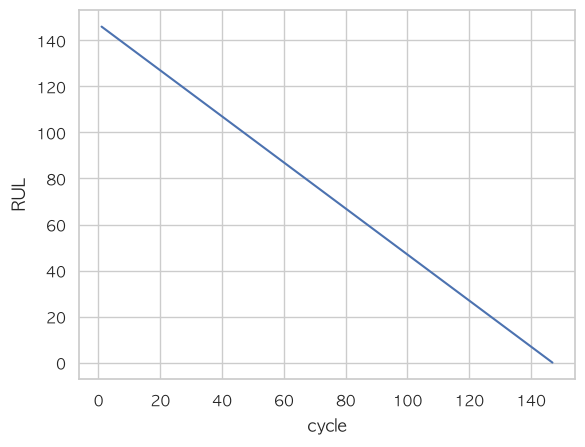

In [41]:
# 코드
plt.plot(unit1['cycle'], unit1['RUL'])
plt.xlabel('cycle')
plt.ylabel('RUL')
plt.show()

## 두 설비의 수명 비교
- 설비끼리는 cycle만으로 비교 불가 — 두 설비를 나란히 두고 직접 확인
- 두 설비의 최대 cycle 비교 + 같은 cycle에서 상태 차이
- 설비마다 고장까지 버티는 cycle 수가 다름을 직접 확인

### 설비별 수명 길이 구하기
groupby로 설비별 최대 cycle(=수명 길이)을 구하고 정렬


In [42]:
# 설비별 가장 큰 cycle = 수명 길이
life = df.groupby('unit_id')['cycle'].max()

# 오래 산 설비부터 일찍 고장난 설비까지 한눈에 보기
life.sort_values()

unit_id
1     147
12    149
9     161
10    163
15    164
13    168
18    172
7     173
6     177
14    177
17    177
20    179
11    187
3     197
5     198
8     198
2     202
19    205
4     205
16    215
Name: cycle, dtype: int64

### 같은 cycle에서 RUL 비교
두 설비의 같은 50 cycle 시점을 각각 골라 RUL 비교

In [43]:
# 1번 엔진의 50 cycle 시점
df[(df['unit_id'] == 1) & (df['cycle'] == 50)]

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
49,1,50,642.436,1587.969,1402.133,552.685,47.461,8.505,97


In [44]:
# 2번 엔진의 50 cycle 시점
df[(df['unit_id'] == 2) & (df['cycle'] == 50)]

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
196,2,50,642.289,1587.573,1405.214,553.069,47.525,8.39,152


## 비교에서 얻는 교훈
- 같은 cycle이라도 설비마다 RUL이 다름
- cycle만으로는 설비끼리 직접 비교할 수 없음

# 27_02 라벨 생성 및 데이터 준비

In [45]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 — failure_soon 라벨 만들기
- RUL ≤ 30 규칙으로 failure_soon 컬럼을 직접 생성
- 27_cmapss_fd001_sample.csv 사용

### 데이터 불러오기
- 이 시점에는 failure_soon 컬럼이 아직 없는 상태


In [46]:
df = pd.read_csv("data/27_cmapss_fd001_sample.csv", encoding="UTF-8")
df.head()

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
0,1,1,641.533,1588.007,1405.656,553.023,46.875,8.405,146
1,1,2,641.861,1584.947,1394.917,554.436,47.396,8.403,145
2,1,3,642.513,1586.896,1394.908,554.178,46.963,8.436,144
3,1,4,641.986,1584.301,1396.013,554.601,47.165,8.384,143
4,1,5,641.853,1587.186,1402.331,554.193,47.313,8.487,142


### 라벨 생성
조건식 → astype(int) → 새 컬럼에 담기

In [47]:
df["failure_soon"] = (df["RUL"] <= 30).astype(int)
df.head()
(df[df["RUL"] <= 30]).head()

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL,failure_soon
116,1,117,642.844,1587.730,1414.415,552.994,47.778,8.487,30,1
117,1,118,643.269,1595.669,1409.967,551.962,47.987,8.521,29,1
118,1,119,643.602,1591.501,1420.234,551.880,47.853,8.523,28,1
119,1,120,642.780,1585.384,1420.341,552.202,47.608,8.529,27,1
120,1,121,643.852,1582.598,1407.450,551.896,48.237,8.546,26,1


### 결과 확인
RUL과 failure_soon을 나란히 비교해 잘 붙었는지 확인

### 경계값 점검
RUL이 정확히 30인 행에서 failure_soon이 1인지 확인

In [48]:
df[df["RUL"] == 30].head()

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL,failure_soon
116,1,117,642.844,1587.730,1414.415,552.994,47.778,8.487,30,1
318,2,172,643.610,1588.950,1420.345,552.547,47.178,8.589,30,1
515,3,167,643.827,1588.888,1428.128,551.716,48.235,8.514,30,1
720,4,175,642.747,1592.564,1411.753,552.044,48.171,8.561,30,1
918,5,168,643.412,1585.870,1413.475,552.077,47.803,8.544,30,1


## 클래스 분포 확인
- 개수와 비율을 직접 보고 불균형을 눈으로 확인
- value_counts로 0과 1의 개수와 비율을 확인
- 우리 데이터가 불균형임을 직접 눈으로 확인

### 개수 세기
0과 1이 각각 몇 개인지 출력

In [49]:
df["failure_soon"].value_counts()

failure_soon
0    2994
1     620
Name: count, dtype: int64

### 비율로 보기
normalize=True 옵션으로 개수 대신 비율 출력

In [50]:
df["failure_soon"].value_counts(normalize=True)

failure_soon
0    0.828445
1    0.171555
Name: proportion, dtype: float64

## 불균형 정리
- 뒤에서 데이터를 나눌 때 stratify로 이 비율을 유지
- 1(곧 고장)의 비율이 작음 = 클래스 불균형


## 임계값 바꿔 분포 비교
- 임계값 선택이 라벨에 주는 영향을 체감하는 실험
- 임계값 20, 30, 50으로 1의 개수가 어떻게 변하는지 비교
- 임계값 선택이 라벨에 주는 영향을 체감

### 임계값 20
RUL 20 이하인 행의 개수 — 임계값 20일 때 1의 개수


In [51]:
len(df[df['RUL'] <= 20])

420

### 임계값 30과 50
임계값 30과 50일 때 1의 개수를 각각 확인

In [52]:
print(len(df[df['RUL'] <= 30]))
print(len(df[df['RUL'] <= 50]))

620
1020


## 임계값 영향 정리
- 같은 데이터인데 임계값만 바꿔도 라벨이 크게 달라짐

## 누수 체험
- 모델 없이도 간단한 비교로 누수의 위력을 확인
- RUL만으로 failure_soon을 완벽히 되살릴 수 있음을 확인


### RUL로 라벨 되살리기
모델 없이 RUL만 가지고 failure_soon을 다시 계산


In [53]:
recalc = (df['RUL'] <= 30).astype(int)
print(recalc)

0       0
1       0
2       0
3       0
4       0
       ..
3609    1
3610    1
3611    1
3612    1
3613    1
Name: RUL, Length: 3614, dtype: int64


### 원래 라벨과 비교
되살린 라벨과 원래 라벨이 전부 같은지 확인


In [54]:
(recalc == df['failure_soon']).all()

np.True_

## 누수의 의미
- RUL 하나로 정답이 완벽히 결정 — 입력에 넣으면 커닝
- RUL은 정답을 그대로 알려 주므로 X에서 제외
- 누수가 있으면 학습은 완벽해도 실전은 무력


## X와 y 구성하기
- 센서만 X에 넣고 RUL은 빼는 게 핵심
- 센서 6개를 X로 구성
- failure_soon을 y로 · unit_id, cycle, RUL은 제외

### feature 목록 정하기
X에 넣을 센서 6개의 이름을 목록으로 정리

In [55]:
feature = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']

### X 만들기
features 목록으로 센서 컬럼들만 골라 X에 담기

In [56]:
X = df[feature]
X.head()

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15
0,641.533,1588.007,1405.656,553.023,46.875,8.405
1,641.861,1584.947,1394.917,554.436,47.396,8.403
2,642.513,1586.896,1394.908,554.178,46.963,8.436
3,641.986,1584.301,1396.013,554.601,47.165,8.384
4,641.853,1587.186,1402.331,554.193,47.313,8.487


### y 만들기
정답인 failure_soon만 골라 y에 담기


In [57]:
y = df['failure_soon']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: failure_soon, dtype: int64

### X/y 확인
입력과 정답은 같은 수의 행을 가져야 함


In [58]:
print(X.shape)
print(y.shape)

(3614, 6)
(3614,)


## 데이터 나누기
- 배운 세 가지 설정을 모두 적용해 실제로 분리
- train_test_split으로 학습용과 평가용 분리
- `test_size 0.2` · `random_state 42` · `stratify=y`

### split 도구 불러오기
scikit-learn에서 데이터를 나눠 주는 도구 불러오기

### 분리 실행
test_size · random_state · stratify 모두 지정해 네 덩어리로 분리

In [59]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 학습용 크기 확인
학습용 입력 X_train과 정답 y_train의 행 수 확인

In [60]:
# 코드
print(X_train.shape)
print(y_train.shape)

(2891, 6)
(2891,)


### 평가용 크기 확인
평가용 입력 X_test와 정답 y_test의 행 수 확인

In [61]:
print(X_test.shape)
print(y_test.shape)

(723, 6)
(723,)


## 분리 정리
- 네 덩어리가 모두 만들어졌는지 확인
- 학습용과 평가용이 약 80 대 20으로 나뉨

## 학습/평가 클래스 비율 비교
- 두 쪽의 클래스 비율을 비교해 stratify의 효과 검증
- 학습용과 평가용의 1 비율이 비슷한지 확인


### 학습용 비율
- 학습용 정답의 0과 1 비율 확인

In [62]:
y_train.value_counts(normalize=True)

failure_soon
0    0.828433
1    0.171567
Name: proportion, dtype: float64

### 평가용 비율
평가용 정답의 0과 1 비율 확인


In [63]:
# 코드
y_test.value_counts(normalize=True)

failure_soon
0    0.828492
1    0.171508
Name: proportion, dtype: float64

## stratify 효과 정리
- 학습용과 평가용 모두 원래의 불균형 비율을 그대로 유지
- 두 쪽 모두 원래 비율을 유지 = stratify 성공

## test_size 바꿔 관찰
- 비율 설정이 분할 크기에 주는 영향을 직접 관찰
- test_size를 바꾸면 학습용/평가용 크기가 달라짐

### test_size 0.3으로
test_size를 0.3으로 바꿔 다시 분할


In [64]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### 크기 비교
test_size 0.2일 때와 0.3일 때의 학습용 크기를 비교


In [65]:
print(X_train.shape)
print(X_train3.shape)

(2891, 6)
(2529, 6)


# 27_03 랜덤 포레스트 고장 임박 분류


In [66]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


In [67]:
df = pd.read_csv('data/27_cmapss_fd001_sample.csv')

df['failure_soon'] = (df['RUL'] <= 30).astype(int)

print(df['failure_soon'].value_counts())
print(df['failure_soon'].value_counts(normalize=True))

feats = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']

X = df[feats]
y = df['failure_soon']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


failure_soon
0    2994
1     620
Name: count, dtype: int64
failure_soon
0    0.828445
1    0.171555
Name: proportion, dtype: float64


## 모델 만들고 학습시키기
모듈 2에서 만든 X_train, y_train으로 랜덤 포레스트 학습

### 분류기 불러오기
`sklearn.ensemble`에서 `RandomForestClassifier` 임포트

In [68]:
# 코드
from sklearn.ensemble import RandomForestClassifier

### 모델 생성
트리 100그루 모델 생성 — 아직 학습 전 빈 상자


In [69]:
# 코드
model = RandomForestClassifier(n_estimators=100, random_state=42)

### 학습 실행
학습용 데이터로 학습 — 평가용은 절대 넣지 않음


In [70]:
# 코드
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### 학습 확인
모델 변수를 출력해 학습이 끝났는지 확인


In [71]:
model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## 예측하고 결과 형태 확인
- 평가용 데이터로 예측 받고 결과가 0/1 배열임을 확인



### 예측 실행
예측 결과를 y_pred에 담고 출력 — 0/1로만 이루어진 배열인가?


In [72]:
# 코드
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,

### 개수 확인
예측 개수와 평가용 행 개수가 같은지 확인


In [73]:
# 코드
print(len(y_pred))
print(X_test.shape)

723
(723, 6)


### 앞부분 보기
예측의 앞 10개만 잘라 보기 — 순서는 X_test와 동일


In [74]:
# 코드
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1])

## 결과 형태 정리
- 예측 = 행마다 0/1이 담긴 배열, 입력과 같은 순서
## predict_proba로 확신도 살펴보기
- 각 행의 0일 확률과 1일 확률 확인 — 강한 확신/애매한 행 비교


### 확률 받기
예측 확률을 받아 앞 5개 확인 — 두 확률을 더하면 1이 되는가?


In [75]:
# 코드
proba = model.predict_proba(X_test)
proba[:5]

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [0.86, 0.14],
       [1.  , 0.  ],
       [1.  , 0.  ]])

### 1일 확률만 보기
두 번째 열, 즉 1일 확률(곧 고장 확률)만 따로 보기


In [76]:
# 코드
proba[:5, 1]

array([0.  , 0.  , 0.14, 0.  , 0.  ])

## 확신도 해석
- 확률이 높은 행과 0.5 부근인 행을 비교해 확신도 차이를 느껴 보기
## random_state 바꿔 다시 학습
- 값을 바꾸면 결과가 조금 달라짐, 같은 값이면 똑같이 재현됨


### 다른 random_state로 학습
random_state를 7로 바꿔 새 모델을 학습하고 예측


In [77]:
# 코드
model2 = RandomForestClassifier(n_estimators=100, random_state = 7)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

### 예측 비교
앞 예측과 새 예측의 앞부분 비교 — 일부 예측이 조금 달라졌는가?

In [78]:
# 코드
print(y_pred[:10])
print(y_pred2[:10])

[0 0 0 0 0 0 0 0 1 1]
[0 0 0 0 0 0 0 0 1 1]


### 같은 값이면 재현
같은 random_state 42로 다시 학습해 결과가 똑같은지 확인


In [79]:
# 코드
model3 = RandomForestClassifier(n_estimators=100, random_state=42)
model3.fit(X_train, y_train)
(model3.predict(X_test) == y_pred).all()


np.True_

## 예측 비교 + feature importance
- 예측·실제 눈 비교 + 어떤 센서가 판단에 크게 쓰였는지 확인


### 예측·실제 나란히 보기
예측과 실제를 한 표에 담아 앞부분 확인


In [80]:
# 코드
# 예측 : y_pred
# 실제 : y_test.values
print(y_pred[:15])
print(y_test.values[:15])

compare = pd.DataFrame({"예측": y_pred, "실제": y_test.values})
compare.head()

[0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
[0 0 0 0 0 0 0 0 1 1 1 0 0 0 0]


,예측,실제
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## 눈으로 일치 세기
- 표를 보며 예측과 실제가 같은 행이 많은지 확인


### 중요 센서 확인
각 센서의 중요도를 큰 순으로 정렬


In [81]:
# 코드
importance = pd.Series(model.feature_importances_, index=feats)
print(importance.sort_values(ascending=False))

sensor_7     0.286819
sensor_15    0.199502
sensor_2     0.167326
sensor_11    0.151536
sensor_4     0.129044
sensor_3     0.065774
dtype: float64


## 중요도 활용
- 중요한 센서 부위를 우선 점검 안내 — 모델 판단이 현장 행동으로
## 예측 결과를 표로 모아 비교
- 예측·실제·곧고장확률을 한 표에 모아 정비 우선순위로 가공


### 결과 표 만들기
예측·실제·곧고장확률을 한 표에 — 확률은 1일 확률 사용


In [82]:
# 코드
result = pd.DataFrame({'예측': y_pred, "실제": y_test.values, "곧고장확률": proba[:, 1]})
result.head(15)

,예측,실제,곧고장확률
0,0,0,0.00
1,0,0,0.00
2,0,0,0.14
3,0,0,0.00
4,0,0,0.00
5,0,0,0.02
6,0,0,0.00
7,0,0,0.21
8,1,1,0.85
9,1,1,0.56


### 곧 고장만 추리기
1로 예측된 행만 추리기 — 우선 점검 후보


In [83]:
# 코드
result[result['예측'] == 1].head(10)

,예측,실제,곧고장확률
8,1,1,0.85
9,1,1,0.56
29,1,1,0.87
32,1,1,0.85
40,1,1,0.90
44,1,1,0.98
49,1,0,0.61
50,1,1,0.98
56,1,1,0.65
63,1,1,0.94


### 우선순위 정렬
곧 고장 확률 높은 순으로 정렬해 우선순위 만들기


In [84]:
# 코드
result.sort_values('곧고장확률', ascending=False).head(10)

,예측,실제,곧고장확률
392,1,1,1.00
209,1,1,1.00
511,1,1,1.00
277,1,1,1.00
444,1,1,1.00
717,1,1,1.00
378,1,1,0.99
381,1,1,0.99
273,1,0,0.99
546,1,1,0.99


## 표 활용 정리
- 정렬된 표 자체가 정비 우선순위 목록 — 그대로 정비팀 전달 가능
## MIMII feature CSV로 정상/이상 분류
- 소리 특징 데이터에 똑같은 분류 흐름 적용 — 데이터만 바뀔 뿐


### 소리 데이터 불러오기
`rms`, `spectral_centroid`, `zero_crossing_rate`, `label` 컬럼 확인

In [85]:
# 코드
mdf = pd.read_csv('data/27_mimii_features_sample.csv')
mdf.head()

,rms,spectral_centroid,zero_crossing_rate,label
0,0.0456,1091.46,0.0809,0
1,0.0453,1747.22,0.0530,0
2,0.0482,1443.32,0.0688,0
3,0.0859,2566.62,0.1627,1
4,0.0504,1816.70,0.0933,0


### X/y 나누기
소리 특징 세 개를 입력 mX로, label을 정답 my로 분리


In [86]:
# 코드
mfeats = ['rms', 'spectral_centroid', 'zero_crossing_rate']
mX = mdf[mfeats]

my = mdf['label']

### 학습용/평가용 분리
엔진 때와 똑같이 분리 — stratify로 정상/이상 비율 유지


In [87]:
# 코드
mX_train, mX_test, my_train, my_test = train_test_split(mX, my, test_size=0.2, random_state=42, stratify=my)

### 학습과 예측
랜덤 포레스트로 학습하고 예측 — 코드 흐름이 엔진 때와 거의 동일


In [88]:
# 코드
mmodel = RandomForestClassifier(n_estimators=100, random_state=42)
mmodel.fit(mX_train, my_train)
my_pred = mmodel.predict(mX_test)
my_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

## 소리 분류 정리
- 데이터만 바뀌었을 뿐 흐름은 동일 — 분류의 본질은 같음
## 종합 미니 실습 (전체 파이프라인)
- 불러오기 → 라벨 → X/y → 분리 → 학습 → 예측 전 과정을 한 흐름으로


### 불러오기와 라벨
데이터를 불러오고 RUL로 failure_soon 라벨 만들기

In [89]:
df = pd.read_csv("data/27_cmapss_fd001_sample.csv", encoding = "UTF-8")
df.head()

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
0,1,1,641.533,1588.007,1405.656,553.023,46.875,8.405,146
1,1,2,641.861,1584.947,1394.917,554.436,47.396,8.403,145
2,1,3,642.513,1586.896,1394.908,554.178,46.963,8.436,144
3,1,4,641.986,1584.301,1396.013,554.601,47.165,8.384,143
4,1,5,641.853,1587.186,1402.331,554.193,47.313,8.487,142


In [90]:
df["failure_soon"] = (df["RUL"] <= 30).astype(int)
df.head()

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL,failure_soon
0,1,1,641.533,1588.007,1405.656,553.023,46.875,8.405,146,0
1,1,2,641.861,1584.947,1394.917,554.436,47.396,8.403,145,0
2,1,3,642.513,1586.896,1394.908,554.178,46.963,8.436,144,0
3,1,4,641.986,1584.301,1396.013,554.601,47.165,8.384,143,0
4,1,5,641.853,1587.186,1402.331,554.193,47.313,8.487,142,0


### X/y 구성
센서 여섯 개를 X로, failure_soon을 y로 — RUL이 X에 없는지 확인


In [91]:
features = ['sensor_2', 'sensor_3', 'sensor_4','sensor_7','sensor_11']
X = df[features]
y = df["failure_soon"]

print("RUL" in X.columns.tolist())

False


### 데이터 분리
학습용과 평가용으로 나누기 — stratify=y로 비율 유지


In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### 학습과 예측
랜덤 포레스트로 학습하고 예측 — 여섯 단계를 막힘 없이 이었나?


In [93]:
model = RandomForestClassifier(n_estimators=100, random_state=42) # 트리 100?
model.fit(X_train, y_train)
model3 = RandomForestClassifier(n_estimators=100, random_state=42) # 트리 100?
model3.fit(X_train3, y_train3)

y_pred = model.predict(X_test)
y_pred3 = model3.predict(X_test3)

In [94]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy3 = accuracy_score(y_test3, y_pred3)

print(f"Test size 0.2 정확도: {accuracy:.4f}")
print(f"Test size 0.3 정확도: {accuracy3:.4f}")

Test size 0.2 정확도: 0.9225
Test size 0.3 정확도: 0.9207


test_size의 차이 즉, 테스트 데이터가 20, 30일 때 랜덤포레스트의 성능이 얼마나 차이나는가 

## 종합 완성 점검
- 여섯 단계를 스스로 완성 — 오류가 나면 어느 단계인지 찾아 고치기
## 종합 결과 읽고 정리
- 예측·실제·확신도·중요 센서를 정비 우선순위로 해석하며 마무리


### 결과 표와 눈비교
예측·실제·곧고장확률을 모아 앞부분 눈비교 — 점수는 다음 파트


In [95]:
proba = model.predict_proba(X_test)
result = pd.DataFrame({"예측" : y_pred, "실제" : y_test.values, "곧고장확률" : proba[:,1]})

In [96]:
# 코드
result.sort_values('곧고장확률', ascending=False).head(10)
pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)


sensor_7     0.334249
sensor_2     0.210007
sensor_11    0.206386
sensor_4     0.166322
sensor_3     0.083036
dtype: float64

## 한 문장으로 정리
- 곧 고장 확률 높은 설비부터 점검, 중요 센서 부위 우선 살피기, 사람이 검토

# 28_01 혼동행렬 기반 분류 평가

# 01 정확도와 그 한계
모델 채점의 첫 단추 — 정확도의 정의, 그리고 불균형이 만드는 함정


### 데이터 로드와 X·y 분리
CSV를 불러와 입력 X(센서 6종)와 정답 y(failure_soon)으로 분리


In [97]:
df = pd.read_csv("data/28_cmapss_fd001_sample.csv", encoding = "UTF-8")
df.head()

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL,failure_soon
0,643.239,1598.756,1409.063,546.905,48.021,8.411,40,0
1,644.115,1589.055,1404.093,547.132,46.564,8.449,69,0
2,643.177,1593.635,1401.598,545.802,48.356,8.731,3,1
3,644.941,1593.509,1419.771,548.299,48.153,8.342,77,0
4,643.050,1614.132,1416.601,546.202,48.013,8.524,11,1


In [98]:
features = ['sensor_2','sensor_3','sensor_4','sensor_7','sensor_11','sensor_15']
X = df[features]
y = df["failure_soon"]

### 분할·학습·예측
학습용·평가용으로 나눠 `RandomForest` 학습 후 예측 — 오늘 채점의 재료


In [99]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(random_state=42).fit(X_train,y_train)
model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [100]:
y_pred = model.predict(X_test)

### 손계산과 함수 대조
같은 자리의 개수를 직접 세어 전체로 나눈 값과 함수 결과 비교

In [101]:
hand = (y_test == y_pred).sum() # 같으면 1
print("직접계산 :",hand/len(y_test))
print("함수계산 :", accuracy_score(y_test, y_pred))

직접계산 : 0.8733333333333333
함수계산 : 0.8733333333333333


### 더미 분류기로 기준선 만들기
`most_frequent` 전략 — 항상 가장 많은 클래스로만 예측하는 모델

In [102]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print("베이스라인: ", dummy.score(X_test, y_test))

베이스라인:  0.8


### 클래스 비율 확인
정상(0)과 고장 임박(1)의 개수·비율 확인 — 1이 얼마나 적은지 눈으로 확인


In [103]:
print(y.value_counts())
print(y.value_counts(normalize=True))

failure_soon
0    781
1    219
Name: count, dtype: int64
failure_soon
0    0.781
1    0.219
Name: proportion, dtype: float64


### 무조건 정상 예측의 정확도
모두 정상으로 찍어도 정확도가 꽤 높음 — 함정을 눈으로 확인하는 순간


In [104]:
all_normal = np.zeros(len(y_test))
print("무조건 정상", accuracy_score(y_test, all_normal))

무조건 정상 0.8


### 두 모델 정확도 출력
더미와 모델의 정확도를 나란히 출력 — 두 숫자를 비교할 준비


In [105]:
dummy_acc = dummy.score(X_test, y_test)
print('베이스라인: ', dummy_acc)

model_acc = model.score(X_test, y_test)
print('우리 모델: ', model_acc)


베이스라인:  0.8
우리 모델:  0.8733333333333333


### 차이 계산과 판단
두 정확도의 차이를 퍼센트포인트로 — 1~2%p면 학습 거의 안 됨, 10%p 이상이면 의미 있음


In [106]:
gap = model_acc - dummy_acc
print("차이(%p):", round(gap * 100, 2))

차이(%p): 7.33


# 02 혼동행렬
네 칸짜리 성적표 — TP·FN·FP·TN과 설비 비용의 언어


### confusion_matrix()와 출력 순서 주의
ravel로 펼치면 순서대로 tn, fp, fn, tp — 이 순서를 헷갈리면 모든 지표가 엉터리


In [107]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()
print(tn, fp, fn, tp)

225 15 23 37


### 혼동행렬 시각화 (heatmap)
ConfusionMatrixDisplay로 색칠된 표 생성 — 진한 칸이 많은 칸


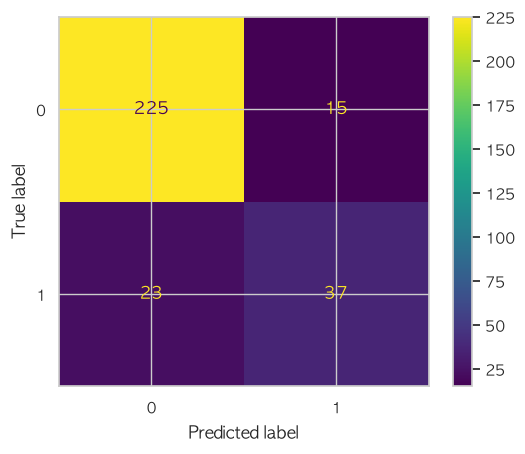

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot()
plt.show()

### 예시로 네 칸 채우기
여섯 대를 한 칸씩 분류 → TP=2, FN=1, FP=1, TN=2 — 함수 결과와 일치 확인


In [109]:
y_true = [1,0,1,1,0,0]
y_hat = [1,0,0, 1,1,0]

# TP = 2, FN=1, FP=1, TN=2

print(confusion_matrix(y_true, y_hat))

[[2 1]
 [1 2]]


### 혼동행렬 생성
우리 모델 예측으로 혼동행렬 출력 — 2×2 배열 확인

In [110]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[225  15]
 [ 23  37]]


### heatmap 시각화
진한 칸이 어디인지 눈으로 확인 — FN 칸이 진하면 놓침 많다는 신호

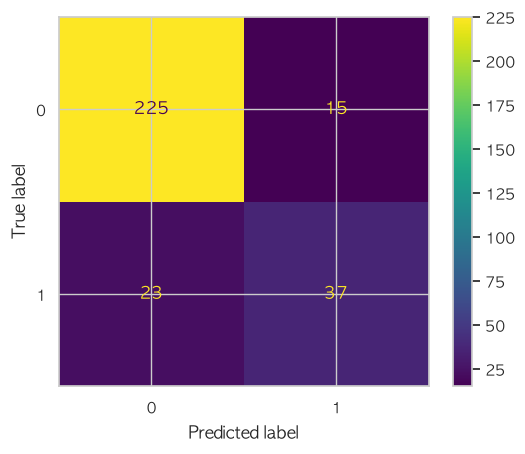

In [111]:
ConfusionMatrixDisplay(cm).plot()
plt.show()

### 네 칸 추출
ravel로 네 칸을 각 변수에 담기 — 순서 tn, fp, fn, tp 엄수


In [112]:
tn, fp, fn, tp = cm.ravel()

print(tp, fp)
print(fn, tn)

37 15
23 225


### 설비 대수로 해석 출력
각 칸을 현장 언어 문장으로 — 숫자가 현장의 의미로 바뀌는 순간


In [113]:
print(f"잡은 고장 {tp}대, 놓친 고장 {fn}대")
print(f"헛 고장 {fp}대, 정상확인 {tn}대")

잡은 고장 37대, 놓친 고장 23대
헛 고장 15대, 정상확인 225대


# 03 정밀도와 재현율
경보의 신뢰도와 놓치지 않는 능력 — 두 지표의 짝과 트레이드오프


In [114]:
# precision_score() 사용법 

from sklearn.metrics import precision_score

p = precision_score(y_test, y_pred)

print(p) # 정밀도 

0.7115384615384616


In [115]:
from sklearn.metrics import recall_score
r = recall_score(y_test, y_pred)
print(r)


0.6166666666666667


### 네 칸으로 손계산
공식에 네 칸을 직접 대입 — 정밀도 = TP/(TP+FP), 재현율 = TP/(TP+FN)


In [116]:
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
print("정밀도:", round(precision, 4))
print("재현율:", round(recall, 4))

정밀도: 0.7115
재현율: 0.6167


### 함수와 대조
손계산과 함수 결과 비교 — 일치하면 공식을 완전히 이해


In [117]:
from sklearn.metrics import precision_score, recall_score

print(f"함수에 의한 정밀도 : {round(precision_score(y_test, y_pred),4)}")
print(f"함수에 의한 재현율 : {round(recall_score(y_test, y_pred),4)}")

함수에 의한 정밀도 : 0.7115
함수에 의한 재현율 : 0.6167


### 세 지표 한 화면 출력
정확도·정밀도·재현율을 함께 출력 — 정확도 높은데 재현율 낮은 식의 치우침 확인


In [118]:
print(f"정확도 : {round(accuracy_score(y_test, y_pred),4)}")
print(f"정밀도 : {round(precision_score(y_test, y_pred),4)}")
print(f"재현율 : {round(recall_score(y_test, y_pred),4)}")

정확도 : 0.8733
정밀도 : 0.7115
재현율 : 0.6167


# 28_02 고장 예측 결과 해석

In [119]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score



try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


# 01 F1-score와 분류 리포트
F1-score란 무엇인가 · 분류 리포트 읽는 순서


### F1 출력
고장 임박 클래스의 F1을 함수 한 줄로 계산해 출력


In [120]:
df = pd.read_csv("data/28_cmapss_fd001_sample.csv", encoding = "UTF-8")

features = ['sensor_2','sensor_3','sensor_4','sensor_7','sensor_11','sensor_15']
X = df[features]
y = df["failure_soon"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42).fit(X_train,y_train)

y_pred = model.predict(X_test)


In [121]:
f1 = f1_score(y_test, y_pred)
print("고장임박 F1 :",round(f1,4))

고장임박 F1 : 0.675


### 리포트 출력과 해석
클래스별 지표를 표로 출력하고 한 줄씩 해석 적기


In [122]:
report = classification_report(y_test, y_pred, target_names = ["정상", "고장임박"])
print(report)

              precision    recall  f1-score   support

          정상       0.91      0.93      0.92       158
        고장임박       0.71      0.64      0.68        42

    accuracy                           0.87       200
   macro avg       0.81      0.79      0.80       200
weighted avg       0.87      0.87      0.87       200



# 02 임계값 조정
임계값을 조정한다는 것 · 임계값과 정밀도·재현율


### 확률 추출과 임계값 적용
고장(1) 확률을 꺼내 임계값별 예측 생성


In [123]:
proba = model.predict_proba(X_test)[:,1]

for t in [0.3, 0.5, 0.7]:
    pred_t = (proba >= t).astype(int)
    print(f"전체데이터 중 {t} 이상인 경우 {pred_t.sum()}개")

전체데이터 중 0.3 이상인 경우 59개
전체데이터 중 0.5 이상인 경우 41개
전체데이터 중 0.7 이상인 경우 20개


### 임계값별 지표 비교
각 임계값의 재현율·정밀도·F1 출력


In [124]:
from sklearn.metrics import precision_score, recall_score, f1_score

for t in [0.3, 0.5, 0.7]:
    pt = (proba >= t).astype(int)

    print(t, round(recall_score(y_test, pt),3), round(precision_score(y_test, pt), 3))

0.3 0.81 0.576
0.5 0.69 0.707
0.7 0.452 0.95


### 비교표 생성
임계값별 지표와 FP·FN을 한 표로


In [125]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score

rows = []

for t in [0.2, 0.3, 0.4, 0.5, 0.7]:
    pt = (proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pt).ravel()

    rows.append([t, recall_score(y_test, pt), fp, fn])

print(pd.DataFrame(rows, columns=["임계값", "재현율", "FP", "FN"]))


   임계값       재현율  FP  FN
0  0.2  0.928571  36   3
1  0.3  0.809524  25   8
2  0.4  0.738095  18  11
3  0.5  0.690476  12  13
4  0.7  0.452381   1  23


# 03 이상탐지 평가와 결과 해석
이상탐지 결과 평가 · 정비 의사결정 해석


### IsolationForest 실행
MIMII 특징으로 이상탐지 학습·예측


In [126]:
from sklearn.ensemble import IsolationForest

dfm = pd.read_csv("data/28_mimii_features_sample.csv", encoding = "UTF-8")

Xm = dfm[['rms', 'spectral_centroid', 'zero_crossing_rate']]

raw = IsolationForest(contamination=0.1, random_state=42).fit_predict(Xm)

raw[:25]

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1])

### 변환과 평가
-1을 1(이상)로 바꿔 라벨과 비교


In [127]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = dfm["label"]
y_iso = (raw == -1).astype(int) # -1(이상) = 1 / 1 정상 = 0

y_iso[:25]

print(confusion_matrix(y_true, y_iso))
print(classification_report(y_true, y_iso))

[[591  36]
 [129  44]]
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       627
           1       0.55      0.25      0.35       173

    accuracy                           0.79       800
   macro avg       0.69      0.60      0.61       800
weighted avg       0.76      0.79      0.76       800



### MIMII 로드와 분할
MIMII 특징과 라벨로 학습 준비 — 지도학습 모드


In [128]:
import pandas as pd
from sklearn.model_selection import train_test_split
Xm = dfm[["rms", "spectral_centroid", "zero_crossing_rate"]]
ym = dfm["label"]
Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.3, random_state=42, stratify=ym)

### 학습과 평가
RandomForest 학습 후 리포트 출력 — 동일 절차


In [129]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
clf = RandomForestClassifier(random_state=42).fit(Xtr, ytr)
pred = clf.predict(Xte)
print(classification_report(yte, pred, target_names=["정상","이상"]))

              precision    recall  f1-score   support

          정상       0.97      0.99      0.98       188
          이상       0.98      0.88      0.93        52

    accuracy                           0.97       240
   macro avg       0.97      0.94      0.96       240
weighted avg       0.97      0.97      0.97       240



### 평가 함수 정의
모델과 평가 데이터를 받는 `evaluate()` 함수


In [130]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix

def evaluate(model, X_test, y_test, name="모델"):   
    pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(name, "재현율", round(recall_score(y_test, pred), 3), "FN", fn)

### 함수로 한 번에 평가
함수에 모델을 넣어 평가 실행 — 모델만 바꿔도 작동


In [131]:
from sklearn.metrics import classification_report

evaluate(model, X_test, y_test, "RandomForest")
print(classification_report(y_test, model.predict(X_test), target_names=["정상","고장임박"]))

RandomForest 재현율 0.643 FN 15
              precision    recall  f1-score   support

          정상       0.91      0.93      0.92       158
        고장임박       0.71      0.64      0.68        42

    accuracy                           0.87       200
   macro avg       0.81      0.79      0.80       200
weighted avg       0.87      0.87      0.87       200



### 두 임계값 예측 생성
임계값 0.5와 0.3으로 예측을 만들고 재현율 비교


In [134]:
proba = model.predict_proba(X_test)[:, 1]
pred_05 = (proba >= 0.5).astype(int)
pred_03 = (proba >= 0.3).astype(int)
from sklearn.metrics import recall_score, precision_score
print("0.5", round(recall_score(y_test, pred_05), 3))
print("0.3", round(recall_score(y_test, pred_03), 3))

0.5 0.69
0.3 0.81


### 리포트 초안 프롬프트
평가 수치를 정비 리포트 초안으로 정리하는 AI 프롬프트


In [133]:
# 코드